# 06 — Model Evaluation

Accuracy is deliberately absent from the headline metrics: at an 11% positive rate, always predicting "no readmission" scores ~89% accuracy while being useless for the actual decision problem. We use ROC-AUC, PR-AUC, calibration, and — the metric that actually matches the decision problem — **recall at fixed intervention capacity**, since a hospital never has capacity to intervene on every patient.

In [1]:
import sys
sys.path.insert(0, '../src')
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve
from evaluation import compare_models, get_calibration

fitted = {name: joblib.load(f'../data/processed/models/{name}.joblib') for name in ['logistic_regression', 'random_forest', 'xgboost']}
X_train, X_test, y_train, y_test = joblib.load('../data/processed/models/splits.joblib')

comparison = compare_models(fitted, X_test, y_test)
comparison

,roc_auc,pr_auc,precision@0.5,recall@0.5,f1@0.5,brier_score,recall@top5pct,recall@top10pct,recall@top20pct
model,,,,,,,,,
logistic_regression,0.6588,0.2157,0.1821,0.5531,0.2740,0.2252,0.1315,0.2226,0.3744
random_forest,0.6620,0.2092,0.1922,0.5228,0.2810,0.2119,0.1302,0.2195,0.3731
xgboost,0.6683,0.2267,0.1869,0.5492,0.2789,0.2123,0.1436,0.2317,0.3896


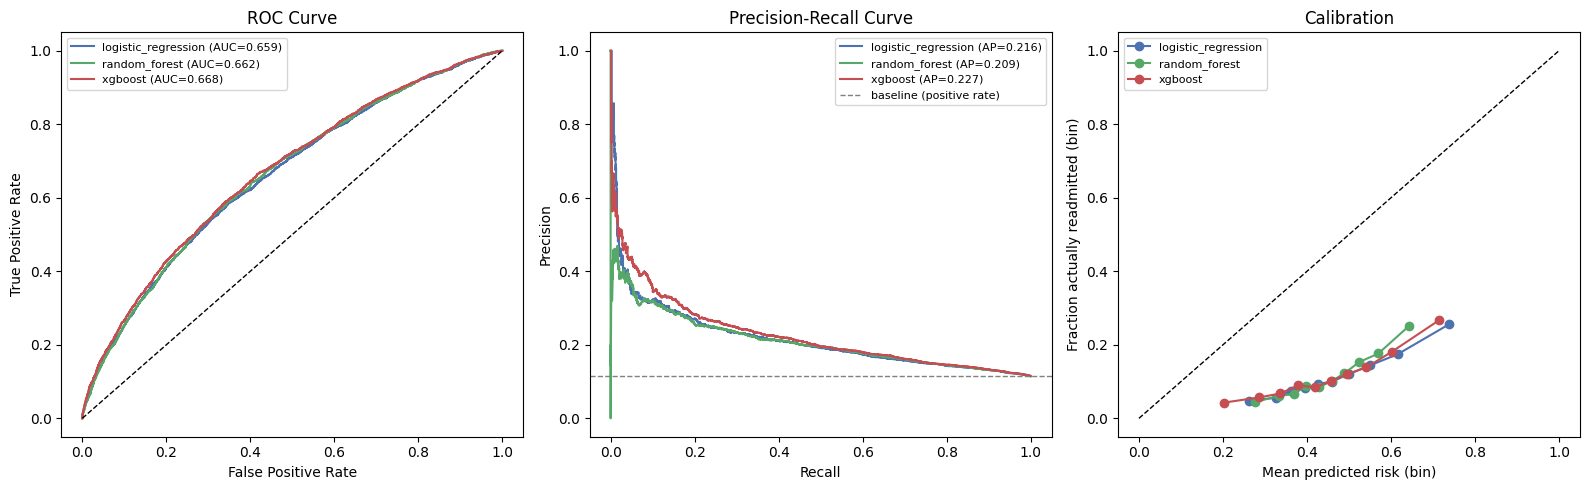

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {'logistic_regression': '#4C72B0', 'random_forest': '#55A868', 'xgboost': '#C44E52'}

for name, pipe in fitted.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={comparison.loc[name, "roc_auc"]:.3f})', color=colors[name])

    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name} (AP={comparison.loc[name, "pr_auc"]:.3f})', color=colors[name])

    mean_pred, frac_pos = get_calibration(pipe, X_test, y_test)
    axes[2].plot(mean_pred, frac_pos, marker='o', label=name, color=colors[name])

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate'); axes[0].set_title('ROC Curve'); axes[0].legend(fontsize=8)

axes[1].axhline(y_test.mean(), color='gray', linestyle='--', linewidth=1, label='baseline (positive rate)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('Precision-Recall Curve'); axes[1].legend(fontsize=8)

axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[2].set_xlabel('Mean predicted risk (bin)'); axes[2].set_ylabel('Fraction actually readmitted (bin)'); axes[2].set_title('Calibration'); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Reading the results:** XGBoost has the best ROC-AUC and PR-AUC of the three, though the margin over Logistic Regression is modest — consistent with published work on this exact dataset (typical reported AUC in the 0.63-0.68 range; this is a genuinely hard prediction problem given 1999-2008 EHR data with no lab-trend or free-text signal). All three models are reasonably well calibrated in the low-to-mid risk range and undercalibrated at the high end (predicted risk exceeds observed rate for the highest-risk bins) — worth keeping in mind before treating raw predicted probabilities as literal probabilities in the cost/benefit optimization later.

**Recall at fixed capacity** (last 3 columns of the table above) is arguably the more decision-relevant metric than either AUC: it directly answers "if we can only intervene on the top X% of patients by predicted risk, what fraction of the actual 30-day readmissions do we catch?" XGBoost is used going forward as the production model for explainability and optimization.